In [1]:
#import the necessary Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import time
import matplotlib.ticker as ticker
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
import lightgbm as lgb
import plotly.graph_objects as go
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [2]:
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.describe()


,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [4]:
#sort formats for all dates 
df.drop('Row ID',axis = 1, inplace = True) #Dropping the Row ID column
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y') #convert Order dates to pandas datetime format
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')   #convert shipping dates to pandas datetime format
df['Month_order'] = df['Order Date'].dt.to_period('M')
df['Year_order'] = df['Order Date'].dt.to_period('Y')

In [5]:
#sorting data by order date
df.sort_values(by=['Order Date'], inplace=True, ascending=True)

In [6]:
#setting the index to be the date
df.set_index("Order Date", inplace = True)

In [7]:
#check null vals 
print(df.isnull().sum())

Order ID          0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Month_order       0
Year_order        0
dtype: int64


In [8]:
df[df['Postal Code'].isnull()]

,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Month_order,Year_order
Order Date,,,,,,,,,,,,,,,,,,
2016-11-07,CA-2016-162887,2016-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,Vermont,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,2016-11,2016
2016-11-08,CA-2016-117086,2016-11-12,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,Vermont,NaN,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",4404.90,2016-11,2016
2017-01-23,US-2017-165505,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,2017-01,2017
2017-01-23,US-2017-165505,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,2017-01,2017
2017-01-23,US-2017-165505,2017-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,Vermont,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,2017-01,2017
2017-04-06,US-2017-150140,2017-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,Vermont,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,2017-04,2017
2018-01-19,US-2018-127292,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,2018-01,2018
2018-01-19,US-2018-127292,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,2018-01,2018
2018-01-19,US-2018-127292,2018-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,Vermont,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,2018-01,2018


In [9]:
df['Postal Code'] = df['Postal Code'].fillna(5401) #postal code for burlington city bc all records of burlington city has missing postal 

In [10]:
#check again
print(df.isnull().sum())


Order ID         0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Month_order      0
Year_order       0
dtype: int64


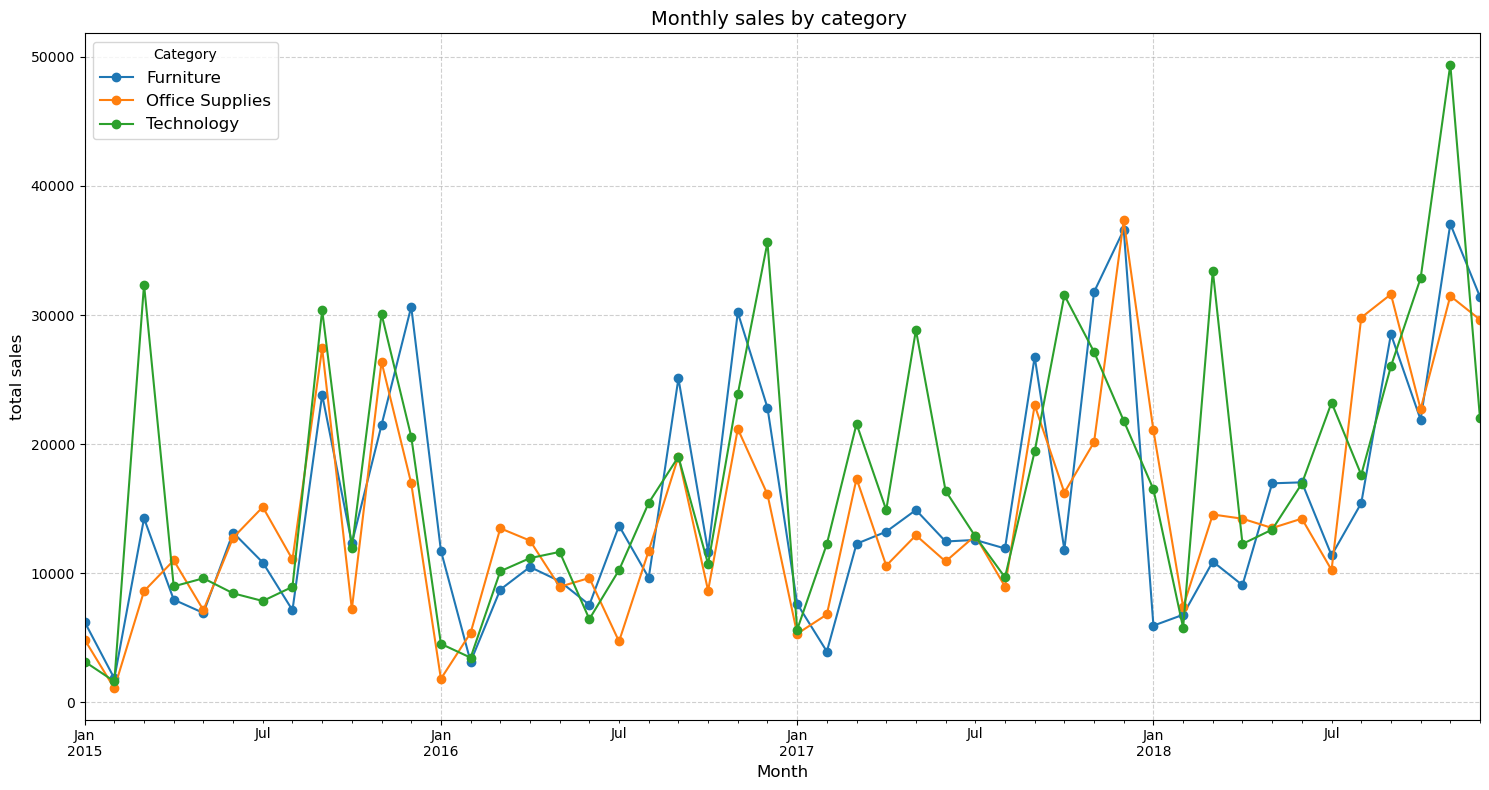

In [11]:
# month sales analysis
monthSalesByCategory = df.groupby(["Month_order", "Category"])["Sales"].sum().unstack()


monthSalesByCategory.plot(kind="line", marker="o", figsize=(15, 8))
plt.title("Monthly sales by category ", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("total sales", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Category", fontsize=12)
plt.tight_layout()

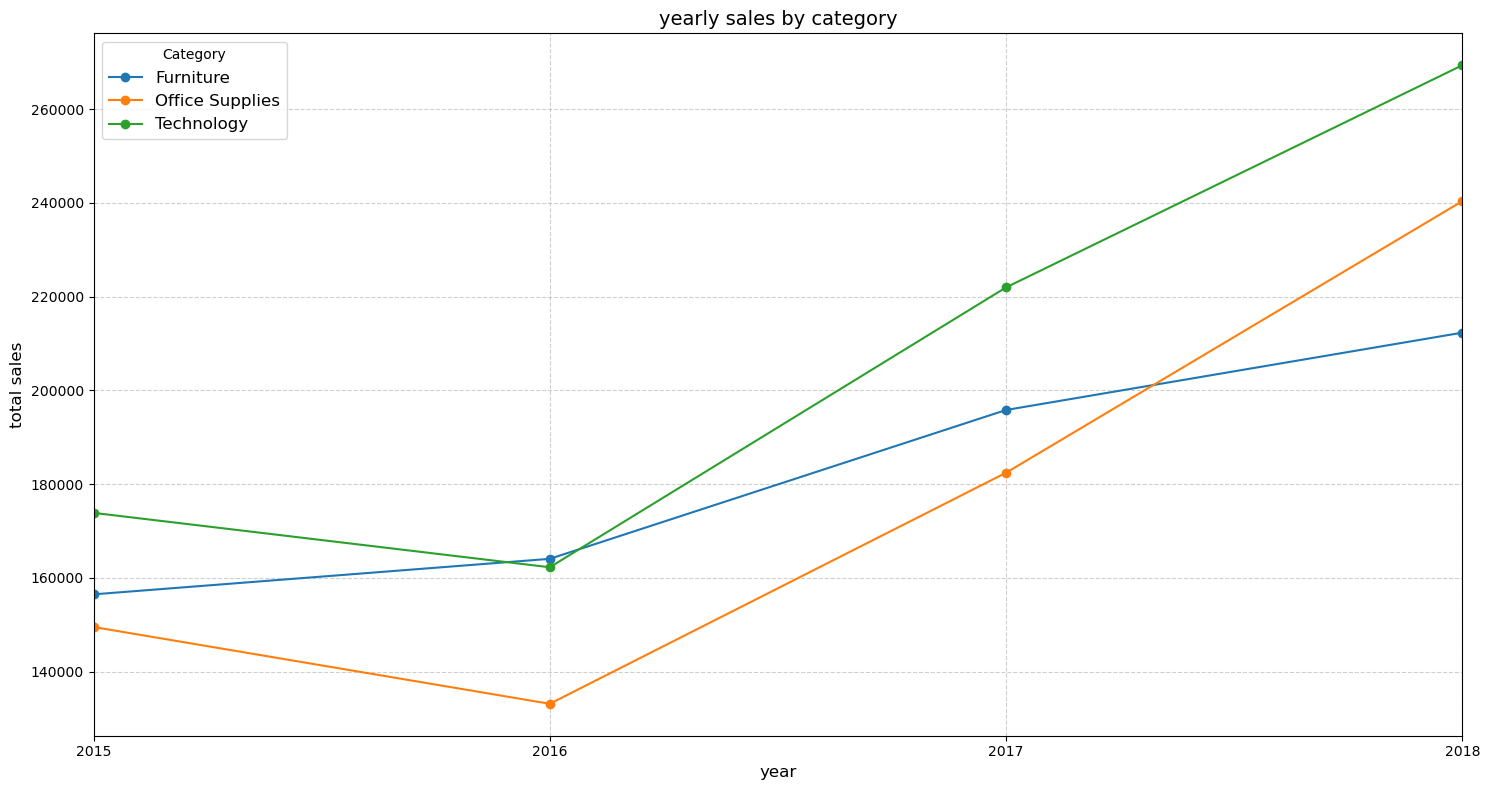

In [12]:
# 4 year sales analysis
yearlyOrder = df.groupby(["Year_order", "Category"])["Sales"].sum().unstack()

yearlyOrder.plot(kind="line", marker="o", figsize=(15, 8))
plt.title("yearly sales by category", fontsize=14)
plt.xlabel("year", fontsize=12)
plt.ylabel("total sales", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Category", fontsize=12)
plt.tight_layout()

In [ ]:
# total revenue per category
Top_category = df.groupby("Category")["Sales"].sum().reset_index().sort_values("Sales", ascending=False)
total_revenue_category = Top_category["Sales"].sum()
total_revenue_category = f"${int(total_revenue_category)}"
print("Total Revenue per Category:", total_revenue_category)
print(Top_category)


Total Revenue per Category: $2261536
          Category        Sales
2       Technology  827455.8730
0        Furniture  728658.5757
1  Office Supplies  705422.3340


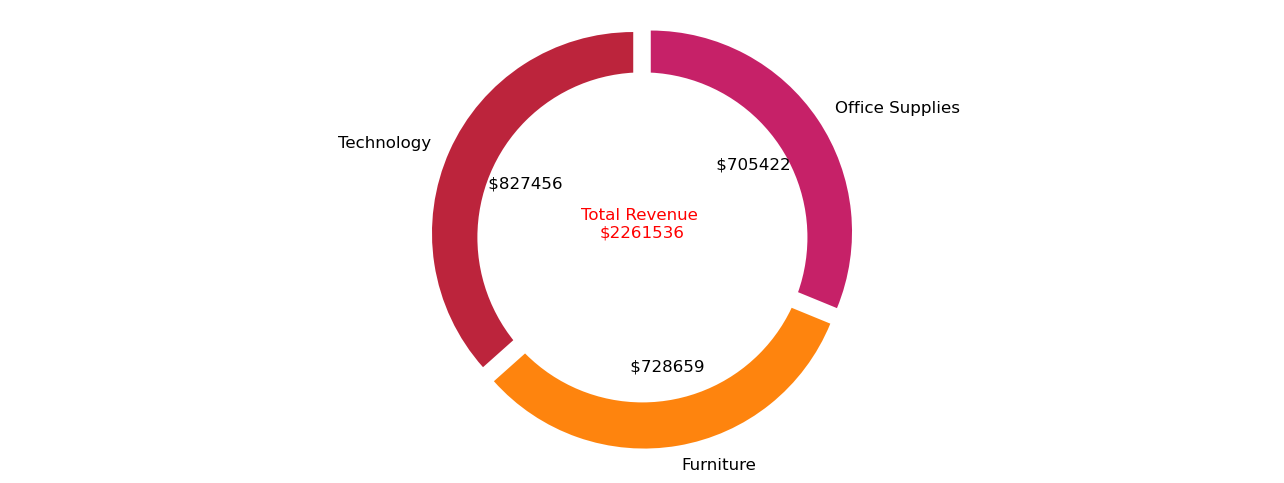

In [14]:
# pie chart for top 3 cat
plt.rcParams["figure.figsize"] = (13,5) 
plt.rcParams['font.size'] = 12.0 
plt.rcParams['font.weight'] = 6 

def autopct_format(values): 
    def my_format(pct): 
        total = sum(values) 
        val = int(round(pct*total/100.0))
        return ' ${v:d}'.format(v=val)
    return my_format
colors = ['#BC243C','#FE840E','#C62168']
explode = (0.05,0.05,0.05)
fig1, ax1 = plt.subplots()
ax1.pie(Top_category['Sales'], colors = colors, labels=Top_category['Category'], autopct= autopct_format(Top_category['Sales']), startangle=90,explode=explode)
centre_circle = plt.Circle((0,0),0.82,fc='white') 
fig = plt.gcf()
fig.gca().add_artist(centre_circle) 
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.axis('equal') 
# total revenue generated at the center
label = ax1.annotate('Total Revenue \n'+str(total_revenue_category),color = 'red', xy=(0, 0), fontsize=12, ha="center")
plt.tight_layout()
plt.show()

In [ ]:
# Sort both category and sub-category as per sales
Top_subcat = df.groupby(["Category", "Sub-Category"])["Sales"].sum().reset_index()
Top_subcat = Top_subcat.sort_values("Sales", ascending=False).head(10)  

# Cast Sales column to integer data type
Top_subcat["Sales"] = Top_subcat["Sales"].astype(int)

# Sort values by Category
Top_subcat = Top_subcat.sort_values("Category")

# Reset index
Top_subcat.reset_index(drop=True, inplace=True)

# Calculate the total sales of all categories
Top_subcat_1 = Top_subcat.groupby("Category")["Sales"].sum().reset_index()

print(Top_subcat)
print(Top_subcat_1)


          Category Sub-Category   Sales
0        Furniture       Chairs  322822
1        Furniture       Tables  202810
2        Furniture    Bookcases  113813
3  Office Supplies      Storage  219343
4  Office Supplies      Binders  200028
5  Office Supplies   Appliances  104618
6       Technology       Phones  327782
7       Technology     Machines  189238
8       Technology  Accessories  164186
9       Technology      Copiers  146248
          Category   Sales
0        Furniture  639445
1  Office Supplies  523989
2       Technology  827454


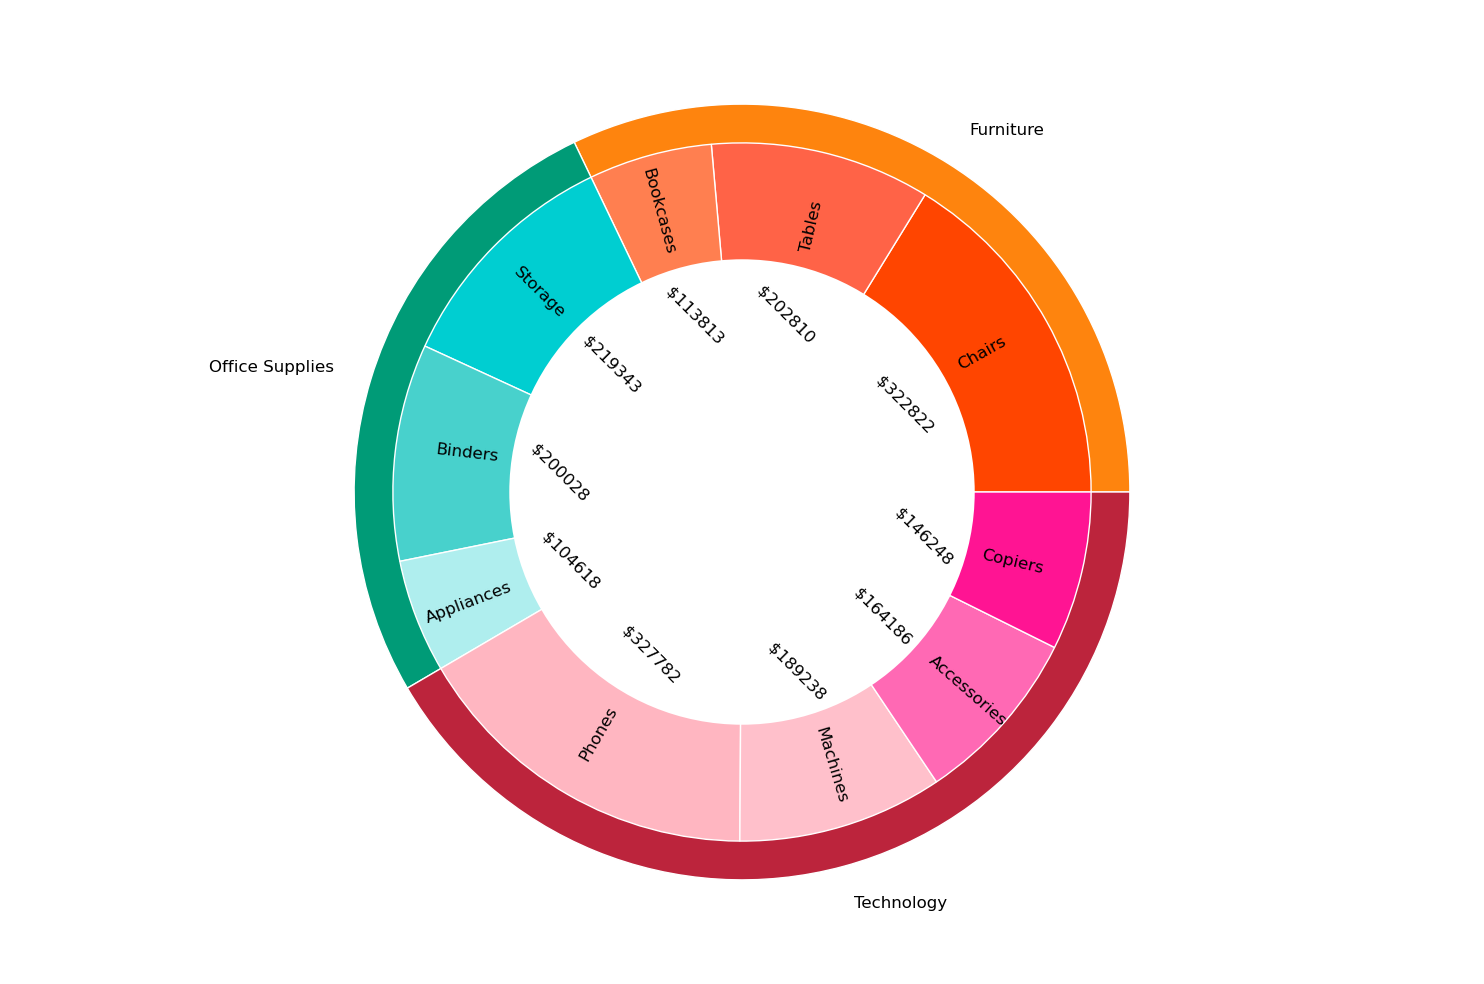

In [ ]:
#pie chart for sub-category
plt.rcParams["figure.figsize"] = (15,10) 
fig, ax = plt.subplots()
ax.axis('equal')
width = 0.1
outer_colors = ['#FE840E','#009B77','#BC243C'] 
inner_colors = ['Orangered','tomato','coral',"darkturquoise","mediumturquoise","paleturquoise","lightpink","pink","hotpink","deeppink"] 
pie = ax.pie(Top_subcat_1['Sales'], radius=1, labels=Top_subcat_1['Category'],colors=outer_colors,wedgeprops=dict(edgecolor='w'))
pie2 = ax.pie(Top_subcat['Sales'], radius=1-width, labels=Top_subcat['Sub-Category'],autopct= autopct_format(Top_subcat['Sales']),labeldistance=0.7,colors=inner_colors,wedgeprops=dict(edgecolor='w'), pctdistance=0.53,rotatelabels =True)
fraction_text_list = pie2[2]
for text in fraction_text_list: 
    text.set_rotation(315) 
centre_circle = plt.Circle((0,0),0.6,fc='white') 
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
# Equal aspect ratio ensures that pie is drawn as a circle
ax1.axis('equal')  
plt.tight_layout()
plt.show()


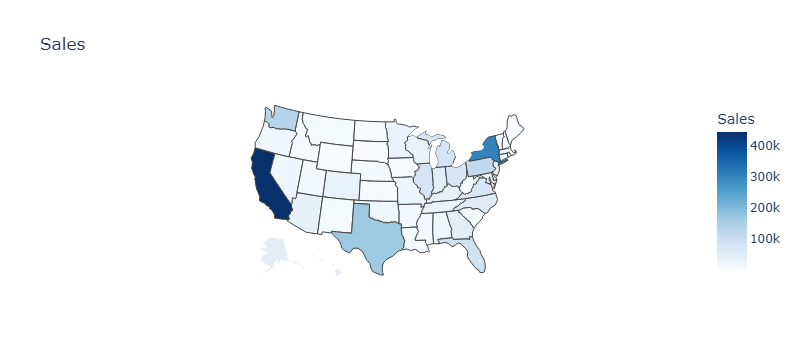

In [ ]:
#Choropleth map 

# Define state and state_code lists
state = ['Alabama', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 
         'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 
         'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 
         'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 
         'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 
         'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']

state_code = ['AL','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA','KS','KY','LA','ME','MD','MA',
              'MI','MN','MS','MO','MT','NE','NV','NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD',
              'TN','TX','UT','VT','VA','WA','WV','WI','WY']

# Create a DataFrame for states and their codes
state_df = pd.DataFrame({'State Code': state_code, 'State': state})

numeric_columns = df.select_dtypes(include=['number']).columns
sales = df.groupby("State")[numeric_columns].sum().sort_values("Sales", ascending=False)

# Reset index to make "State" a column
sales.reset_index(inplace=True)

# Drop "Postal Code" safely using axis=1
if 'Postal Code' in sales.columns:
    sales.drop('Postal Code', axis=1, inplace=True)

sales = sales.sort_values('State', ascending=True).reset_index(drop=True)

# Merge sales with state codes
sales = sales.merge(state_df, on="State", how="left")

# Add text labels
sales['text'] = sales['State'] + '<br>Sales: ' + sales['Sales'].astype(str)

# Create the Choropleth map
fig = go.Figure(data=go.Choropleth(
    locations=sales['State Code'],  # Spatial coordinates
    text=sales['text'],
    z=sales['Sales'].astype(float),  
    locationmode='USA-states',  
    colorscale='Blues',
    colorbar_title="Sales",
))

fig.update_layout(
    title_text='Sales',
    geo_scope='usa',  # Limit map scope to USA
)

fig.show()


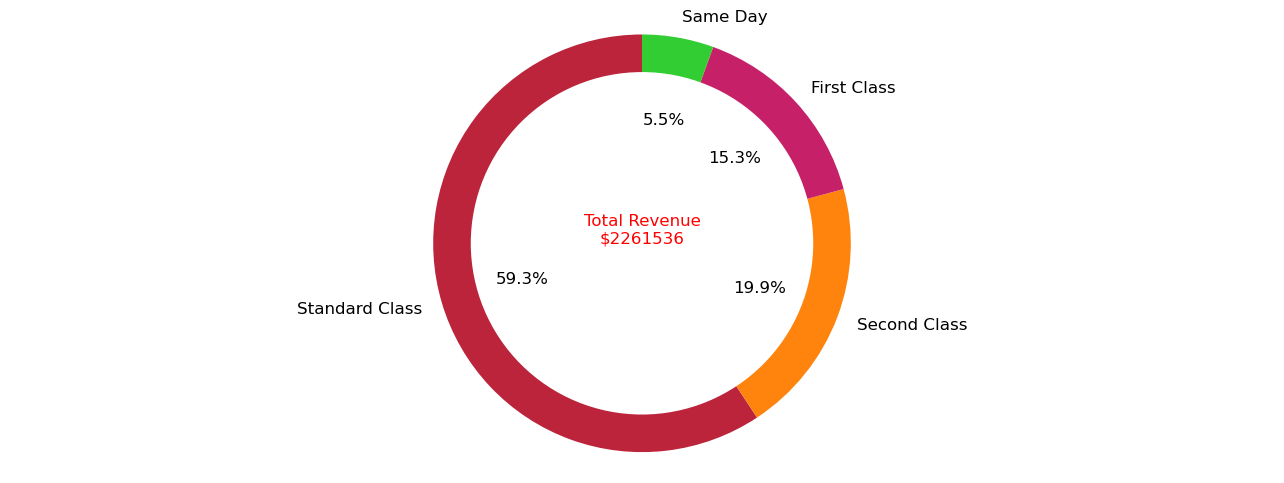

In [18]:
# pie chart of shipping modes
# Group by "Ship Mode" and sum only numeric columns
Top_shipping = df.groupby(["Ship Mode"]).sum(numeric_only=True).sort_values("Sales", ascending=False)

# Keep only the "Sales" column
Top_shipping = Top_shipping[["Sales"]]

# Reset index to add "Ship Mode" back as a column
Top_shipping.reset_index(inplace=True)

# Compute total revenue
total_revenue_ship = Top_shipping["Sales"].sum()
total_revenue_ship = f"${int(total_revenue_ship)}"  # Convert to integer and format as a string with "$"

plt.rcParams["figure.figsize"] = (13, 5)  
plt.rcParams['font.size'] = 12  
plt.rcParams['font.weight'] = 6  
colors = ['#BC243C', '#FE840E', '#C62168', "limegreen"]  

fig1, ax1 = plt.subplots()
ax1.pie(Top_shipping['Sales'], colors=colors, labels=Top_shipping['Ship Mode'], autopct='%1.1f%%', startangle=90)


centre_circle = plt.Circle((0, 0), 0.82, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

ax1.axis('equal')

# Annotate total revenue at the center of the chart
ax1.annotate(f'Total Revenue\n{total_revenue_ship}', color='red', xy=(0, 0), fontsize=12, ha="center")

plt.tight_layout()
plt.show()

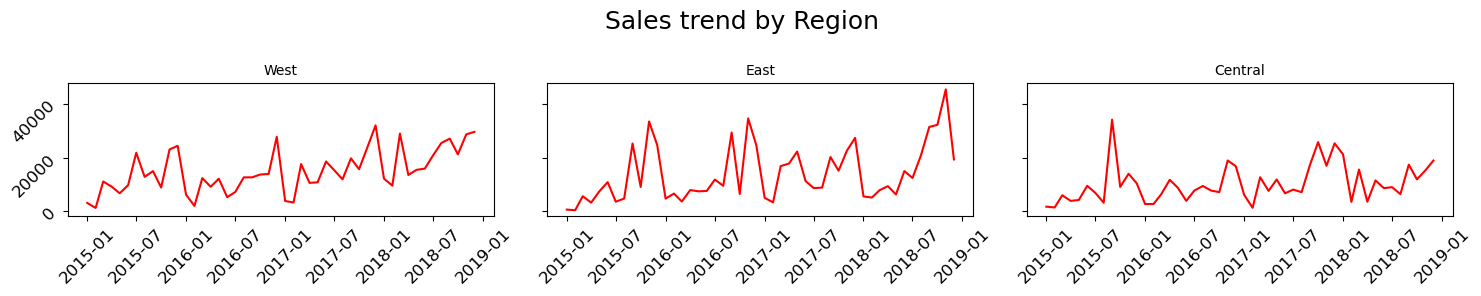

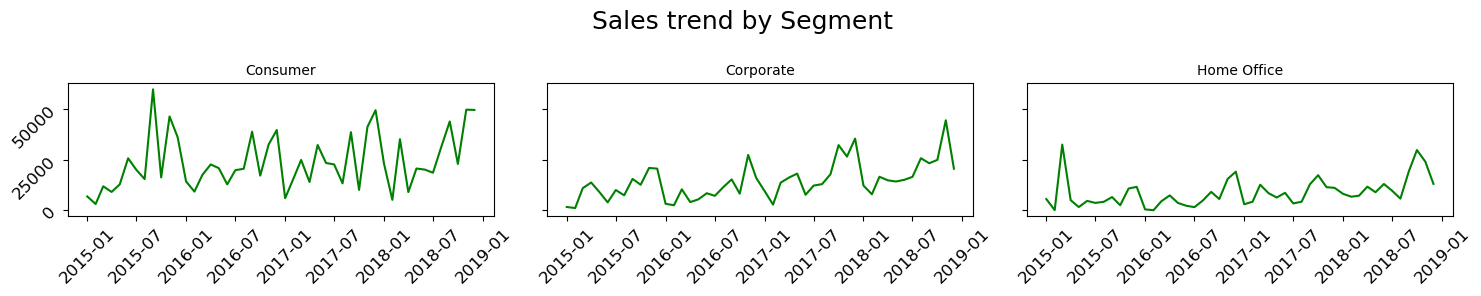

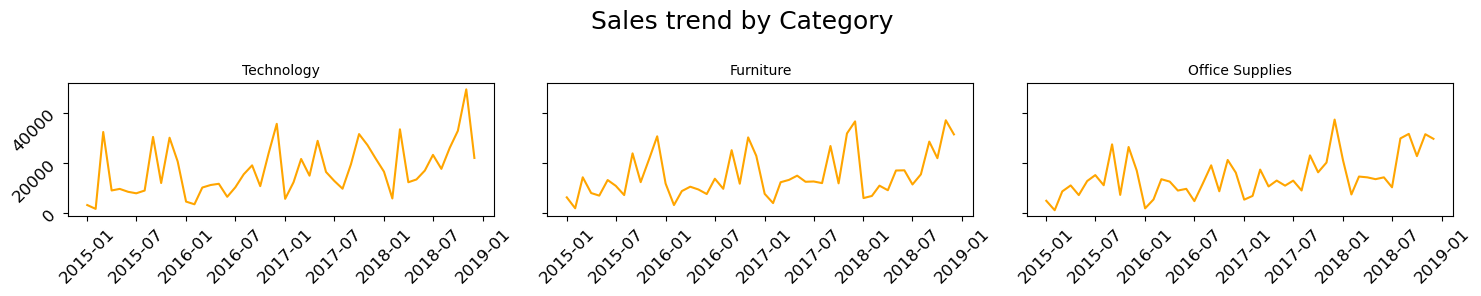

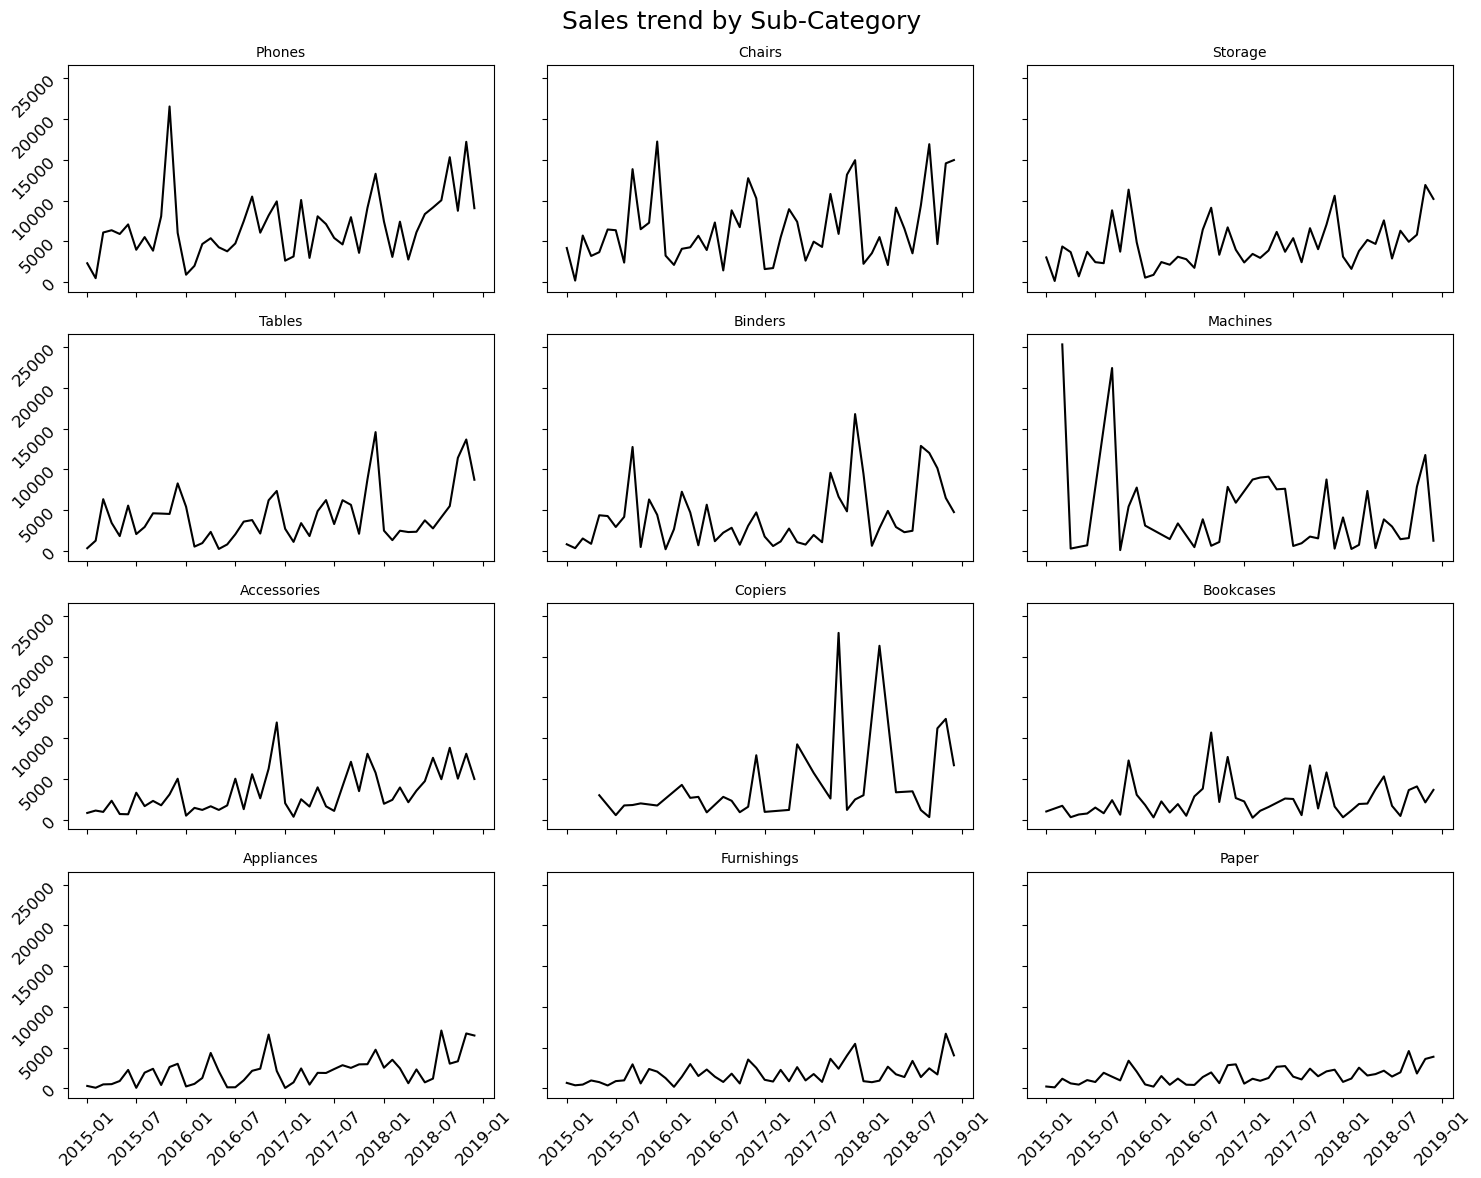

In [19]:
# sales trend per region, segment, category, sub-category
def plot_trend_group(group,size, color='blue'):
    sales_by_group = df.groupby(group)['Sales'].sum() 
    sales_by_group.sort_values(ascending= False, inplace=True) 
    sales_by_group.head(size) # select top records
    # subplots with 3 plots per line
    fig, axes = plt.subplots(int(size/3),3, figsize=(15,size), sharex =True, sharey =True)
    fig.suptitle('Sales trend by {}'.format(group), fontsize=18)

    for ax,group_name in zip(axes.flat, sales_by_group.index):
        sales_group = df[df[group]==group_name]
        sales_group = sales_group.groupby("Month_order")['Sales'].sum()
        sales_group.index = sales_group.index.to_timestamp()
        ax.tick_params(labelrotation=45)
        ax.set_title(group_name, fontsize = 10)
        ax.plot(sales_group, color=color)
    fig.tight_layout()
plot_trend_group('Region',3, 'red') 
plot_trend_group('Segment',3,'green') 
plot_trend_group('Category',3, 'orange') 
plot_trend_group('Sub-Category',12, 'black') 


In [20]:
monthly_sales = df.groupby("Month_order")['Sales'].sum()
monthly_sales = pd.DataFrame(monthly_sales)
monthly_sales['time'] = np.arange(len(monthly_sales.index))
monthly_sales.head()

,Sales,time
Month_order,,
2015-01,14205.707,0
2015-02,4519.892,1
2015-03,55205.797,2
2015-04,27906.855,3
2015-05,23644.303,4


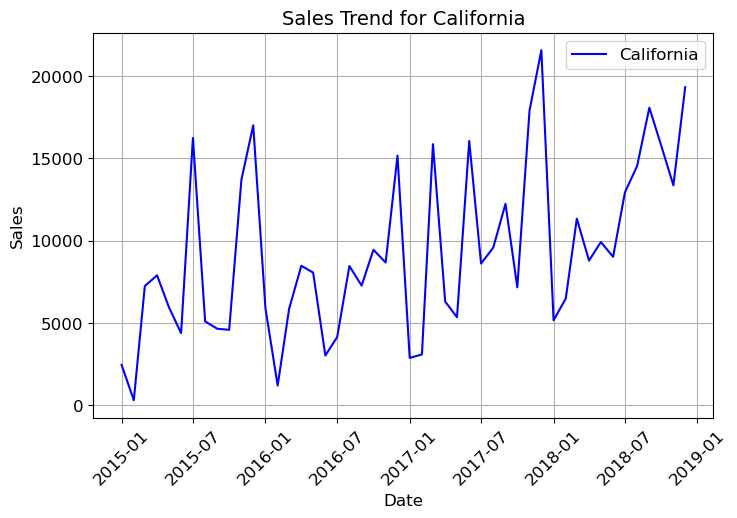

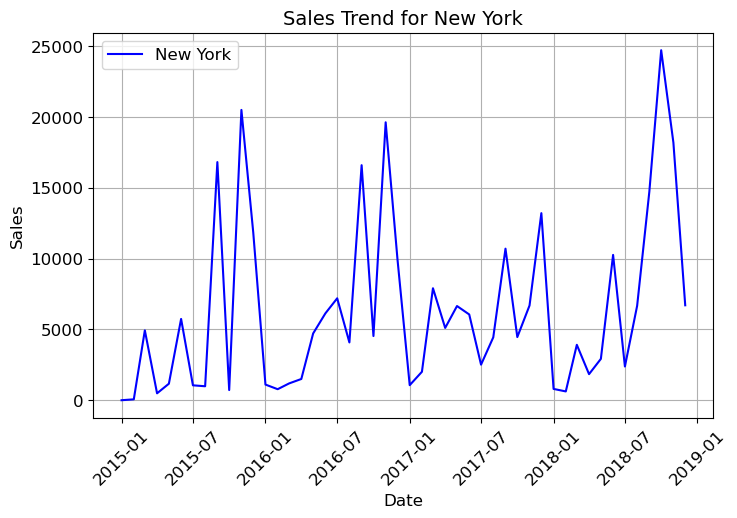

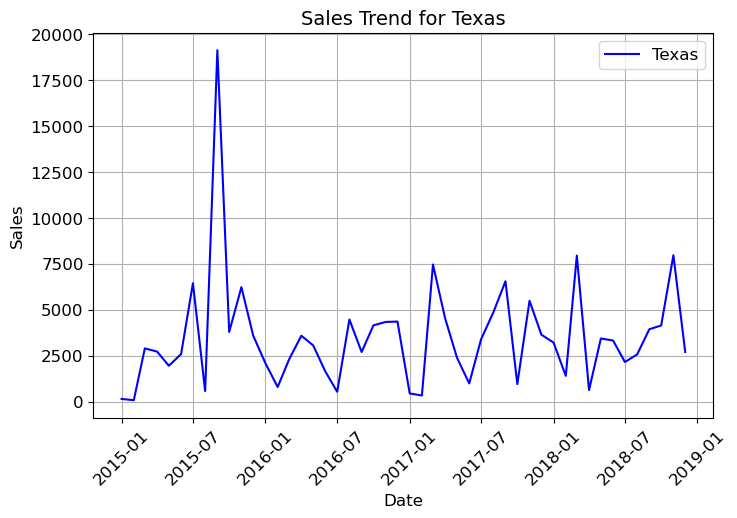

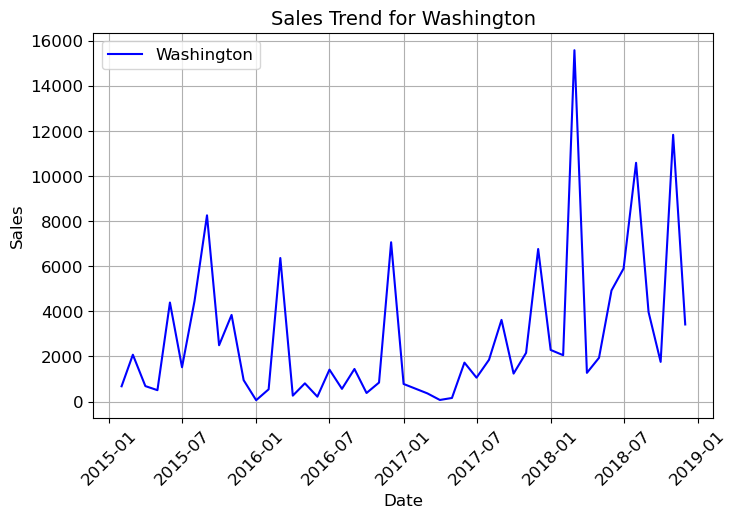

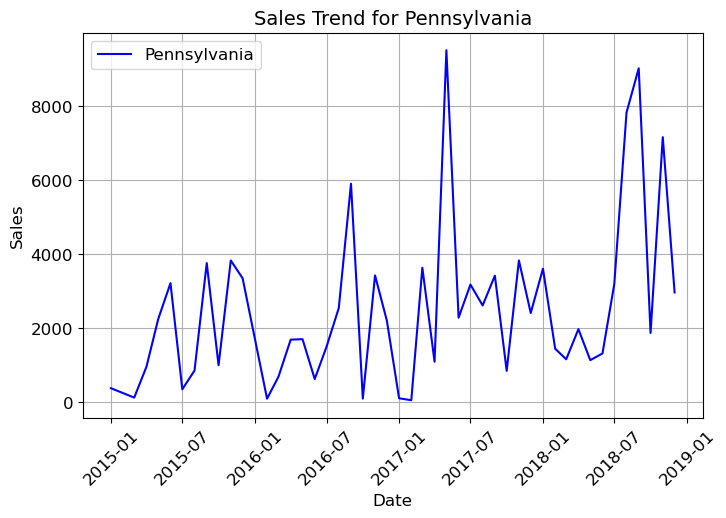

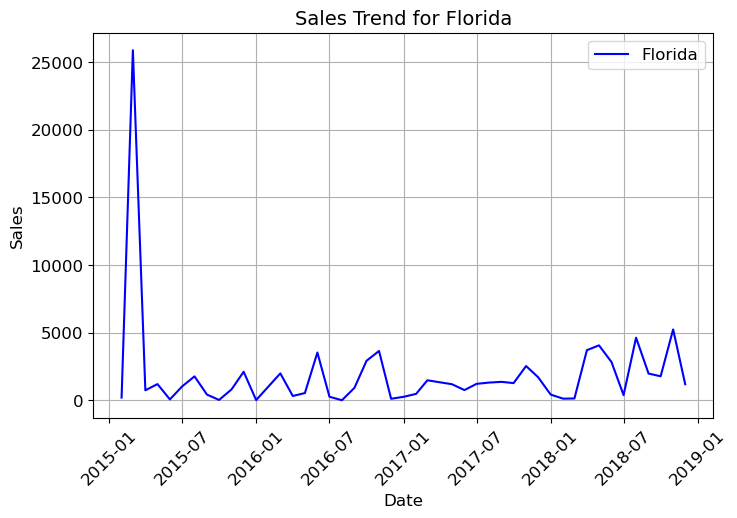

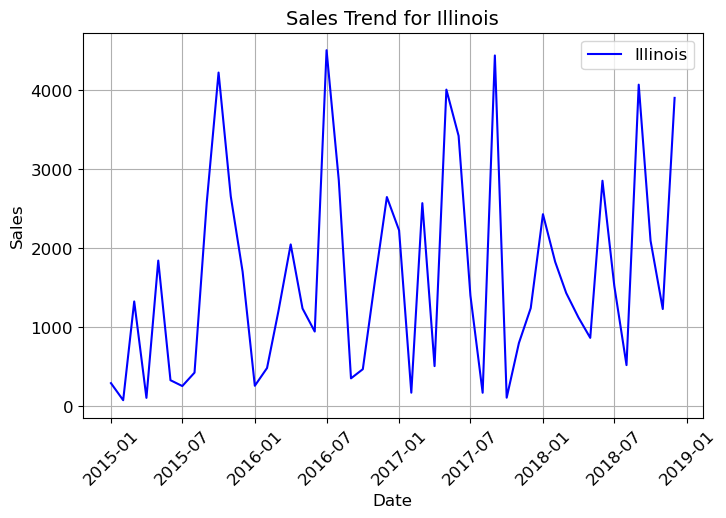

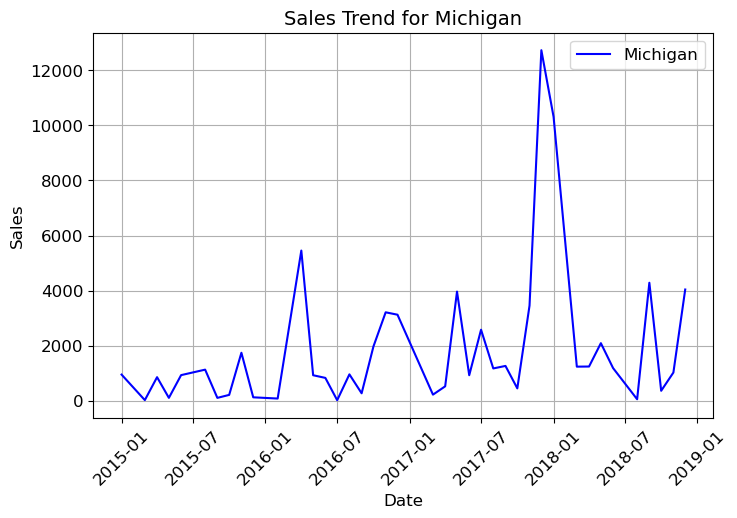

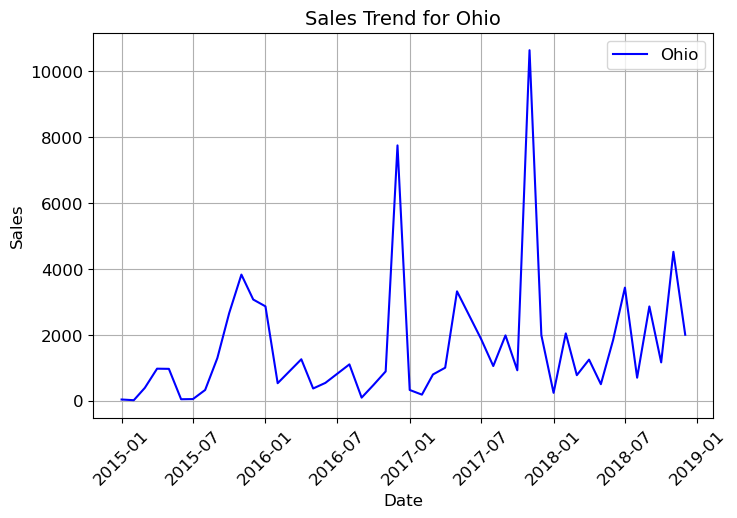

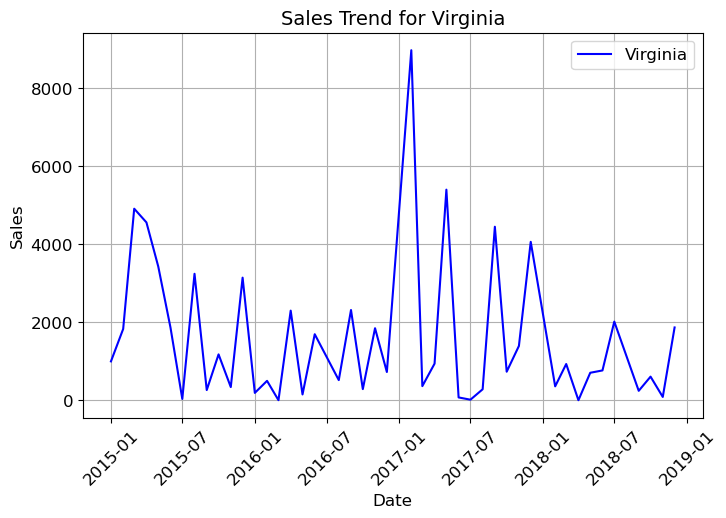

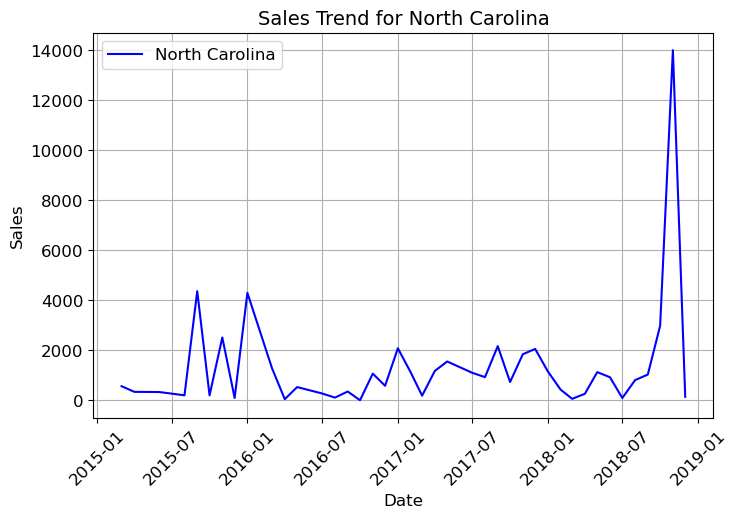

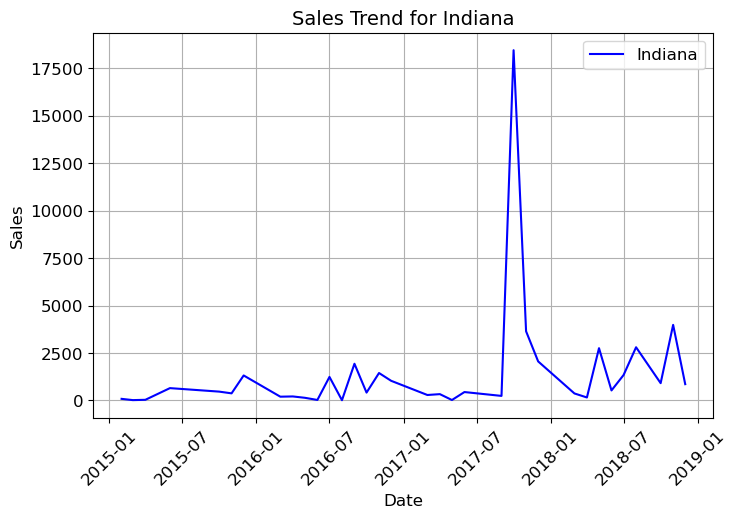

In [21]:
#sales trnd per state 
def plot_trend_per_state(size=12, color='blue'):
    sales_by_state = df.groupby('State')['Sales'].sum()  
    sales_by_state.sort_values(ascending=False, inplace=True) 
    top_states = sales_by_state.head(size).index  # Get the top 'size' states

    for state in top_states:
        state_sales = df[df['State'] == state]
        state_sales = state_sales.groupby("Month_order")['Sales'].sum()
        state_sales.index = state_sales.index.to_timestamp()  # Convert to datetime
        
        plt.figure(figsize=(8, 5)) 
        plt.plot(state_sales, color=color, label=state)
        plt.title(f'Sales Trend for {state}', fontsize=14)
        plt.xlabel('Date')
        plt.ylabel('Sales')
        plt.xticks(rotation=45)
        plt.legend()
        plt.grid(True)
        plt.show()

plot_trend_per_state()


Columns in the dataset: Index(['Order ID', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name',
       'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Month_order', 'Year_order'],
      dtype='object')
Shape of grouped data: (2839, 3)


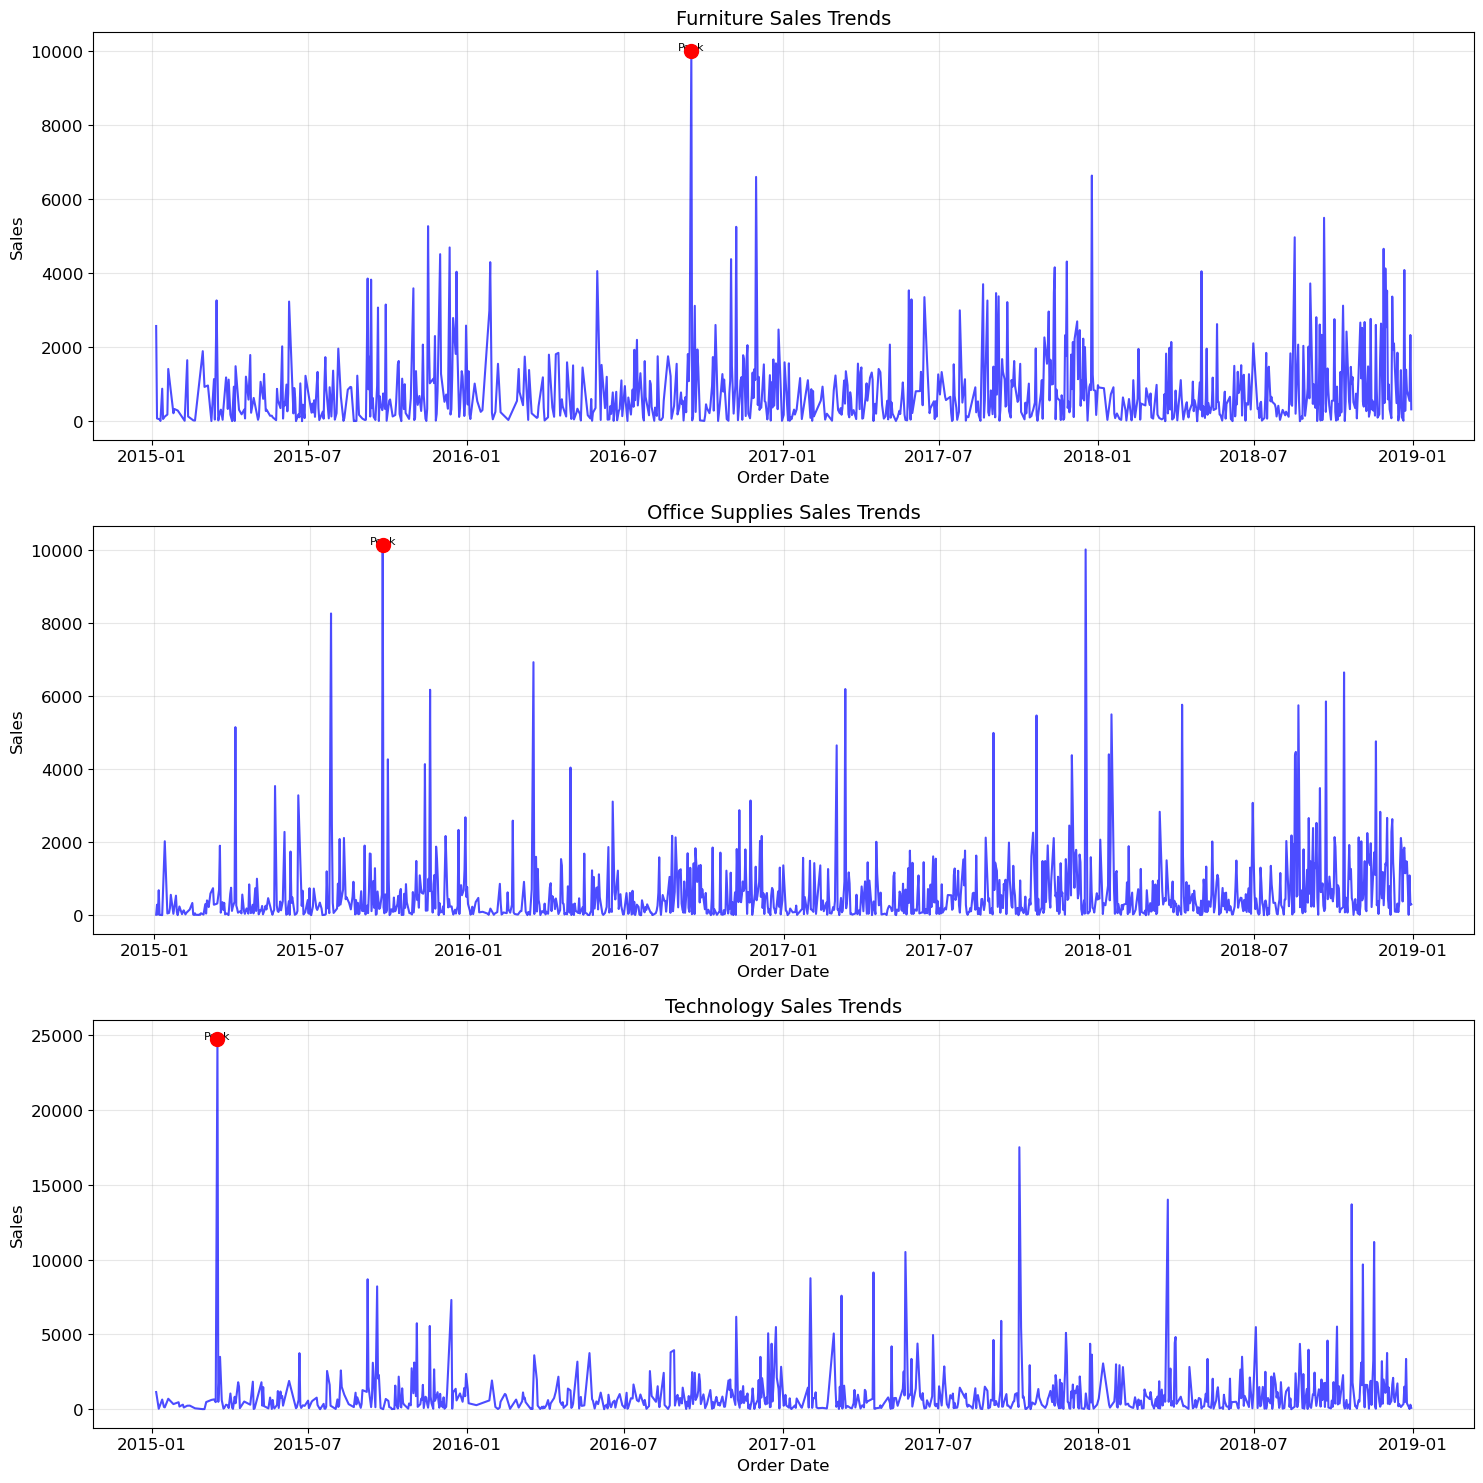


Trends data saved to 'category_trends.csv'


In [ ]:
#sales trend by category
print("Columns in the dataset:", df.columns)

# Group data by Category and Order Date
grouped_data = df.groupby(['Category', 'Order Date']).agg({
    'Sales': 'sum'
}).reset_index()

print("Shape of grouped data:", grouped_data.shape)
categories = grouped_data['Category'].unique()

plt.figure(figsize=(15, len(categories) * 5))  

for i, category in enumerate(categories, 1):
    category_data = grouped_data[grouped_data['Category'] == category]
    
    plt.subplot(len(categories), 1, i)
    plt.plot(category_data['Order Date'], category_data['Sales'], label=category, color='blue', alpha=0.7)
    
    # Highlight peaks (top 3 sales values)
    peak_date = category_data.loc[category_data['Sales'].idxmax(), 'Order Date']
    peak_sales = category_data['Sales'].max()
    plt.scatter(peak_date, peak_sales, color='red', s=100, zorder=5)
    plt.text(peak_date, peak_sales + 10, f"Peak", fontsize=8, ha='center')
    
    plt.title(f"{category} Sales Trends", fontsize=14)
    plt.xlabel("Order Date", fontsize=12)
    plt.ylabel("Sales", fontsize=12)
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

grouped_data.to_csv("category_trends.csv", index=False)
print("\nTrends data saved to 'category_trends.csv'")

Columns in the dataset: Index(['Order ID', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name',
       'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales',
       'Month_order', 'Year_order'],
      dtype='object')
Shape of grouped data: (6480, 4)


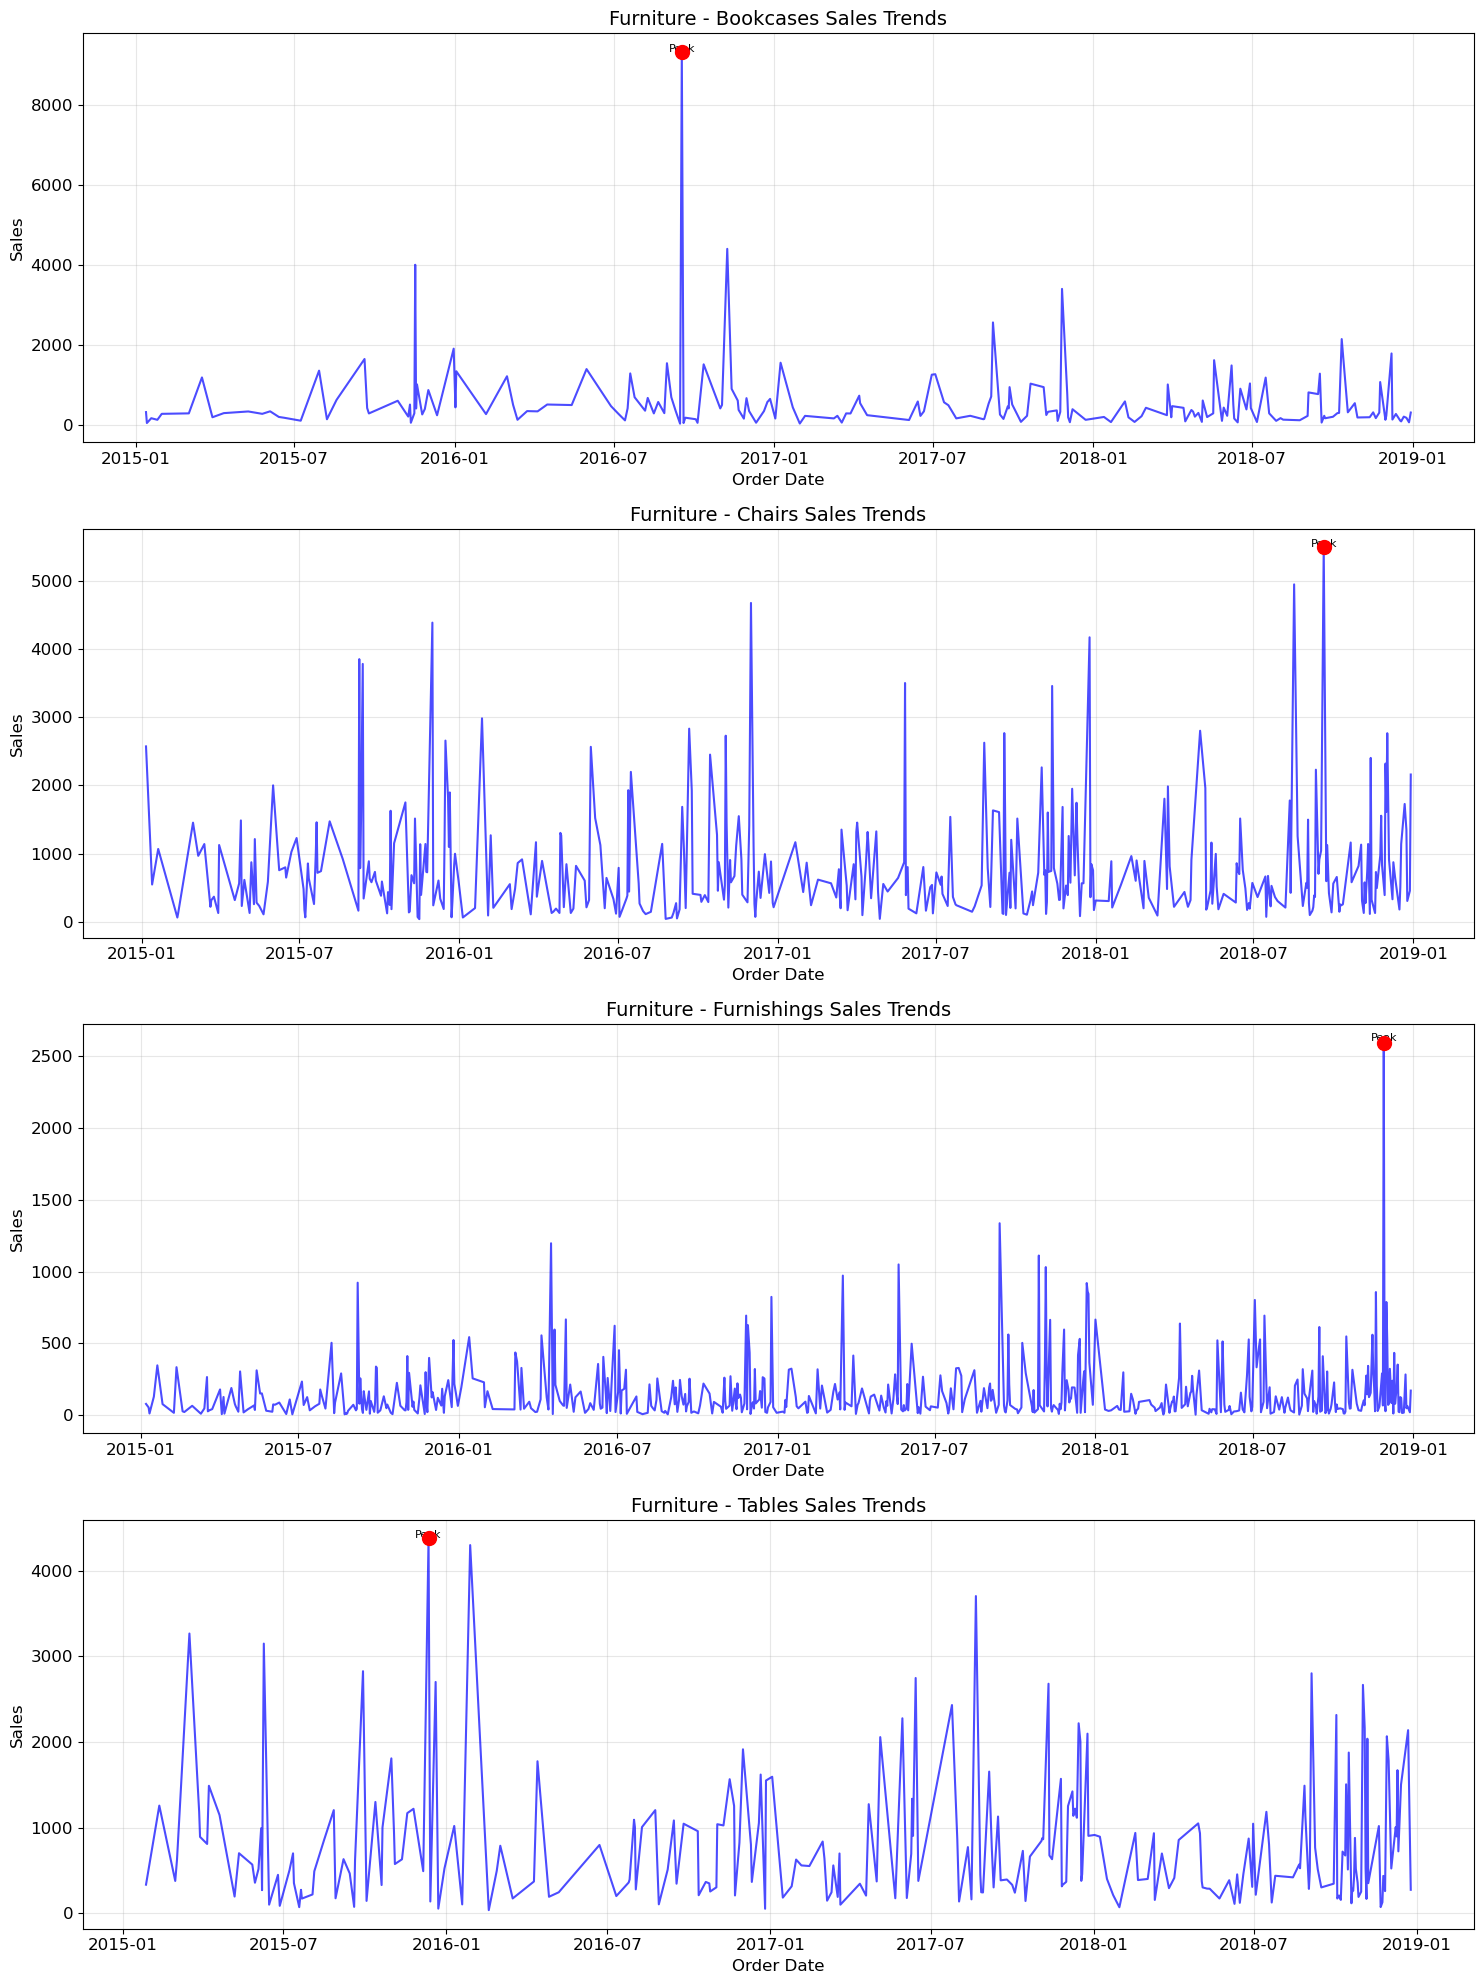

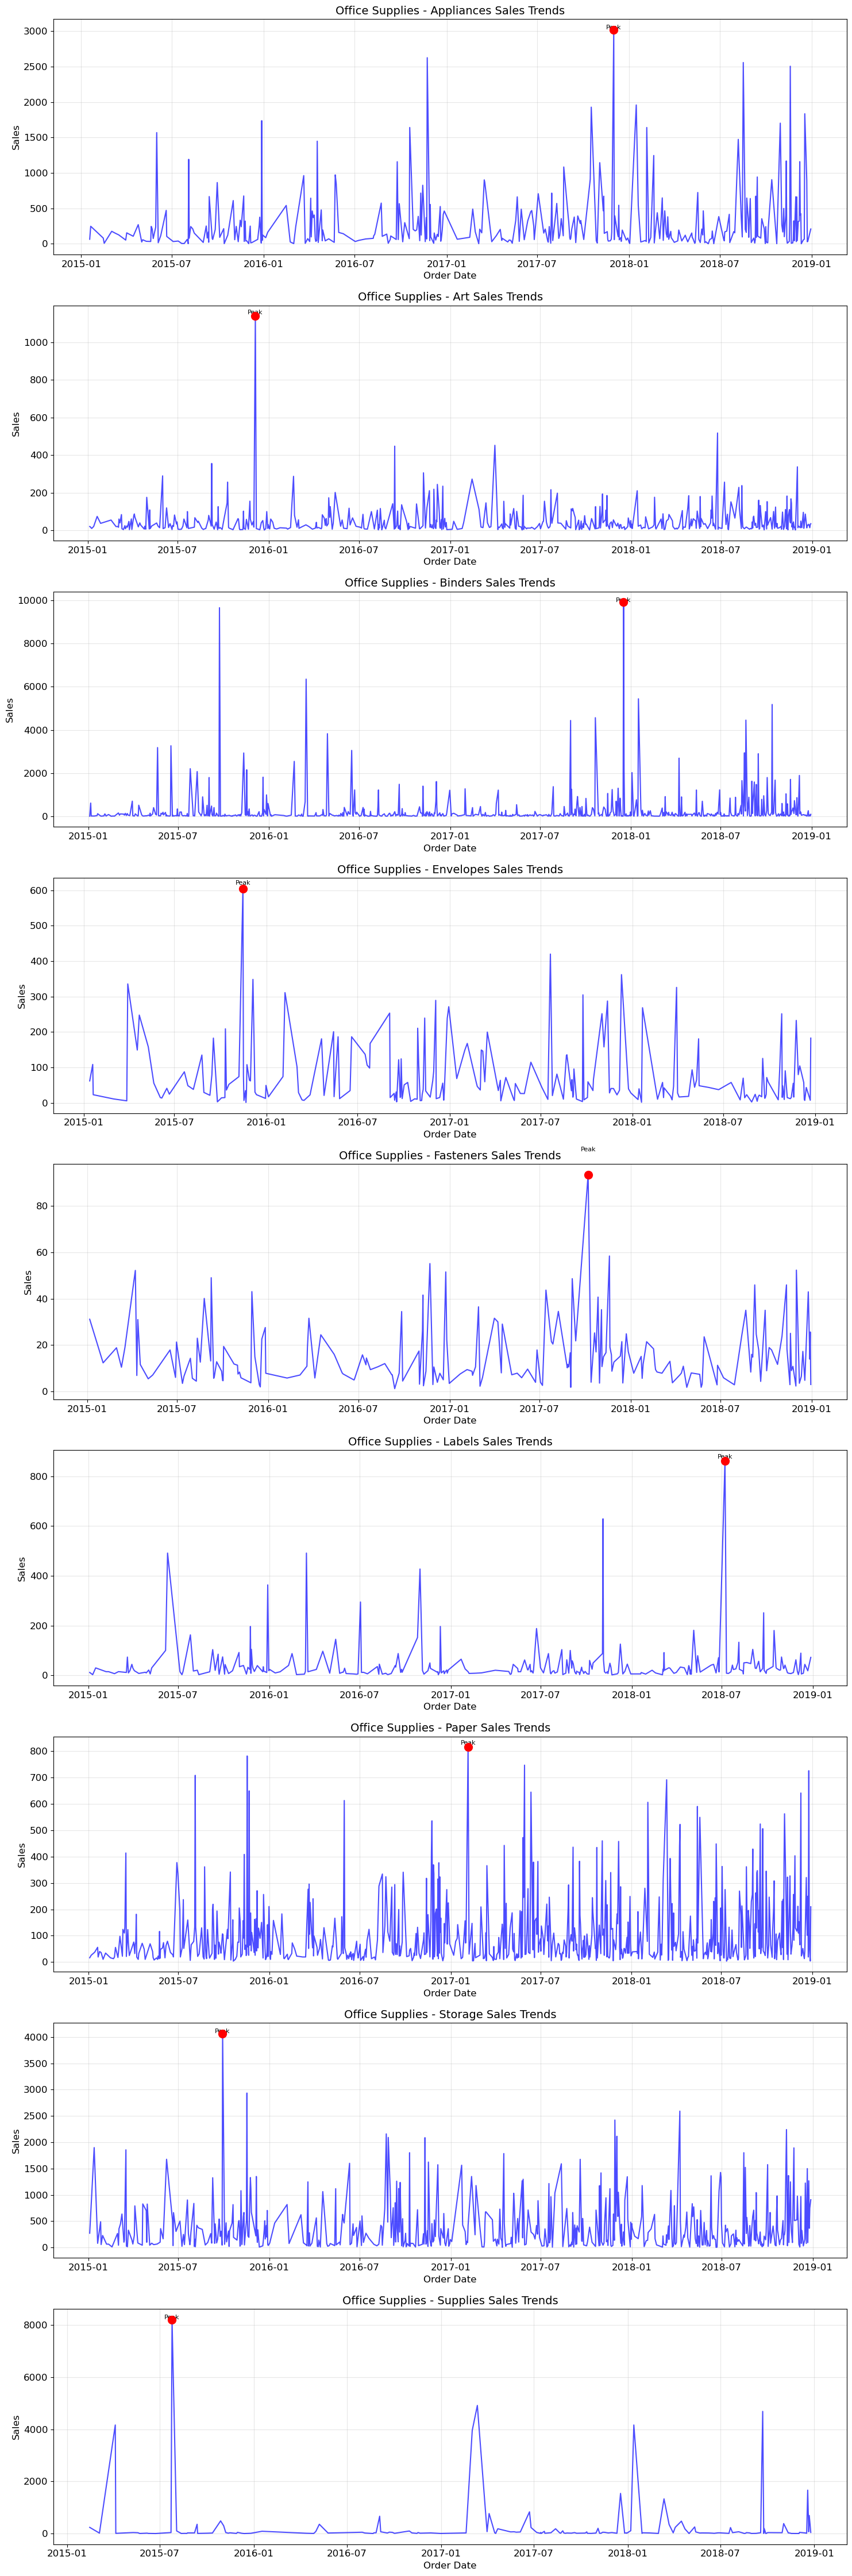

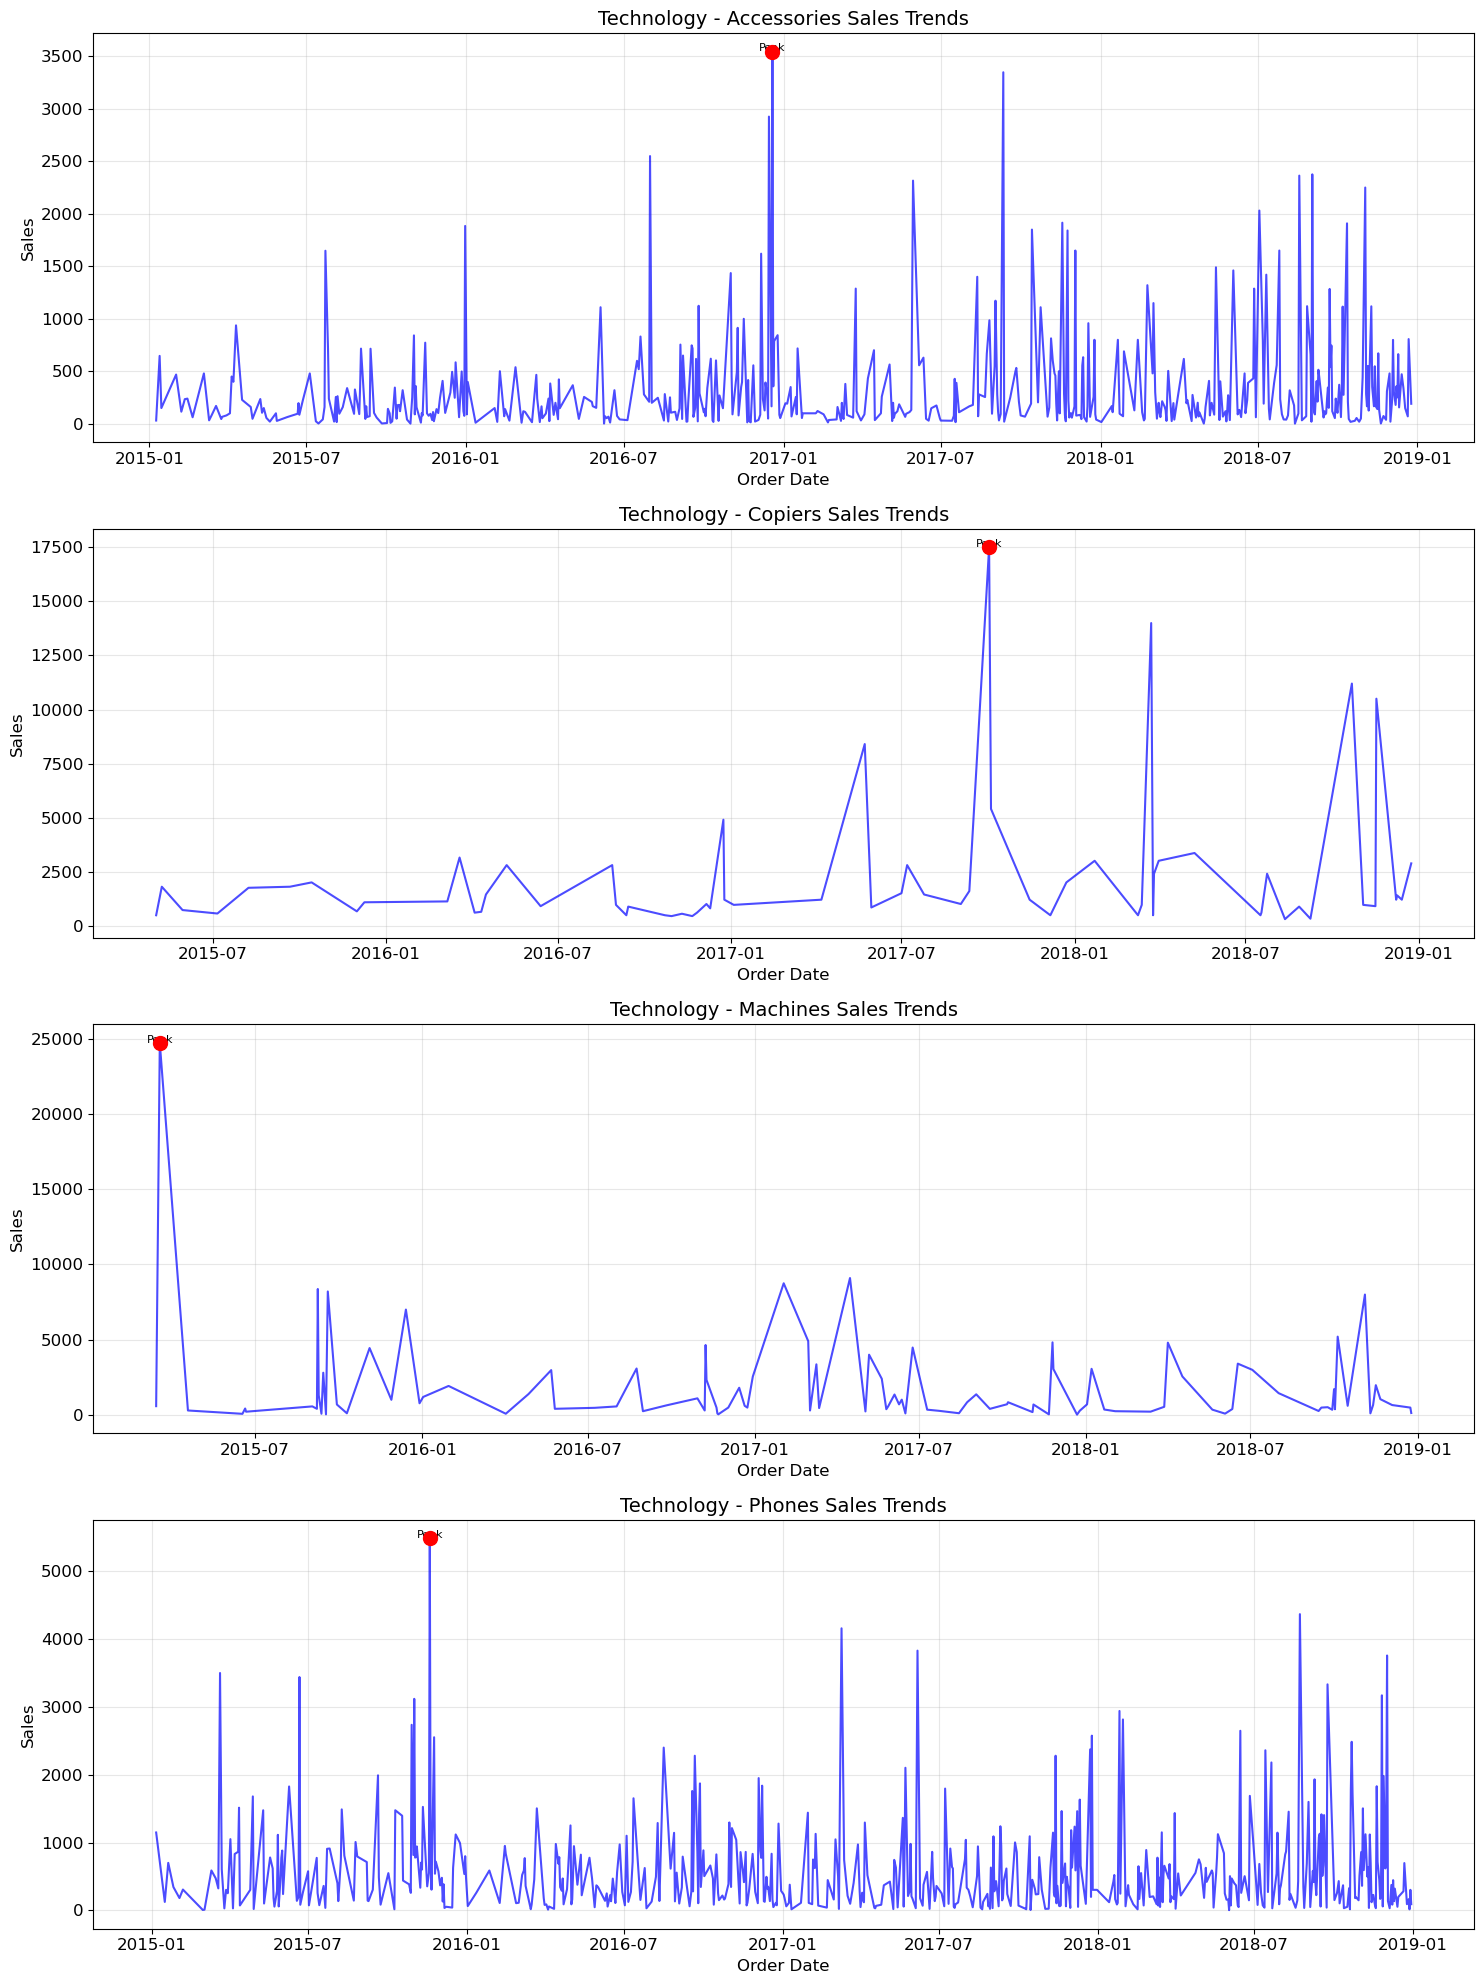

In [ ]:
#sales trend by sub-category 
# Sort the data by 'Order Date'
df.sort_values(by='Order Date', inplace=True)

# Inspect column names
print("Columns in the dataset:", df.columns)

# Group data by Category, Sub-Category, and Order Date
grouped_data = df.groupby(['Category', 'Sub-Category', 'Order Date']).agg({
    'Sales': 'sum'
}).reset_index()

# Check grouped data shape
print("Shape of grouped data:", grouped_data.shape)

categories = grouped_data['Category'].unique()

for category in categories:
    category_data = grouped_data[grouped_data['Category'] == category]
    subcategories = category_data['Sub-Category'].unique()
    
    plt.figure(figsize=(15, len(subcategories) * 5))
    
    for i, subcategory in enumerate(subcategories, 1):
        subcategory_data = category_data[category_data['Sub-Category'] == subcategory]
        plt.subplot(len(subcategories), 1, i)
        plt.plot(subcategory_data['Order Date'], subcategory_data['Sales'], label=subcategory, color='blue', alpha=0.7)
        
        # Highlight peaks (top 3 sales values)
        peak_date = subcategory_data.loc[subcategory_data['Sales'].idxmax(), 'Order Date']
        peak_sales = subcategory_data['Sales'].max()
        plt.scatter(peak_date, peak_sales, color='red', s=100, zorder=5)
        plt.text(peak_date, peak_sales + 10, f"Peak", fontsize=8, ha='center')
        
        plt.title(f"{category} - {subcategory} Sales Trends", fontsize=14)
        plt.xlabel("Order Date", fontsize=12)
        plt.ylabel("Sales", fontsize=12)
        plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()



=== Random Forest ===
✅ Best Params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10, 'bootstrap': True}
📉 MSE: 1.63
📈 RMSE: 1.28
📊 R² Score: 0.38


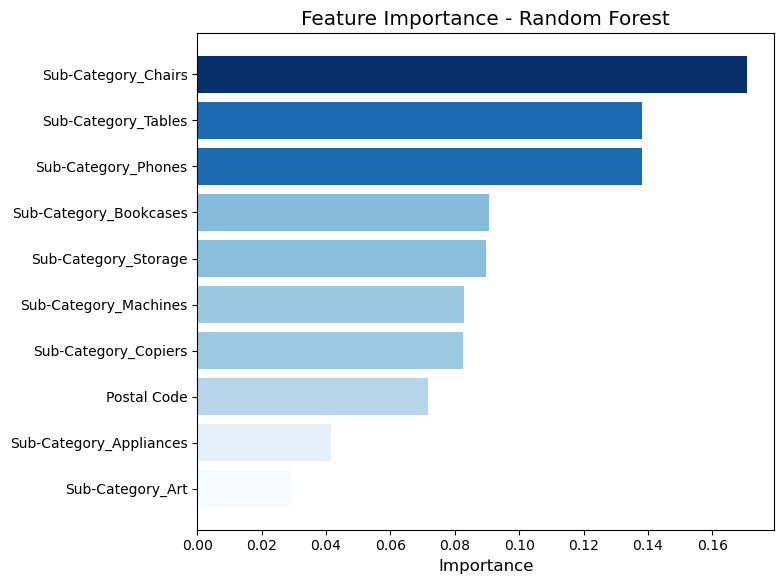

Top 10 Important Features:
                    Feature  Importance
13      Sub-Category_Chairs    0.170645
24      Sub-Category_Tables    0.138174
21      Sub-Category_Phones    0.138129
12   Sub-Category_Bookcases    0.090503
22     Sub-Category_Storage    0.089682
19    Sub-Category_Machines    0.082861
14     Sub-Category_Copiers    0.082582
0               Postal Code    0.071704
9   Sub-Category_Appliances    0.041484
10         Sub-Category_Art    0.029151

=== Gradient Boosting ===
✅ Best Params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
📉 MSE: 1.47
📈 RMSE: 1.21
📊 R² Score: 0.44


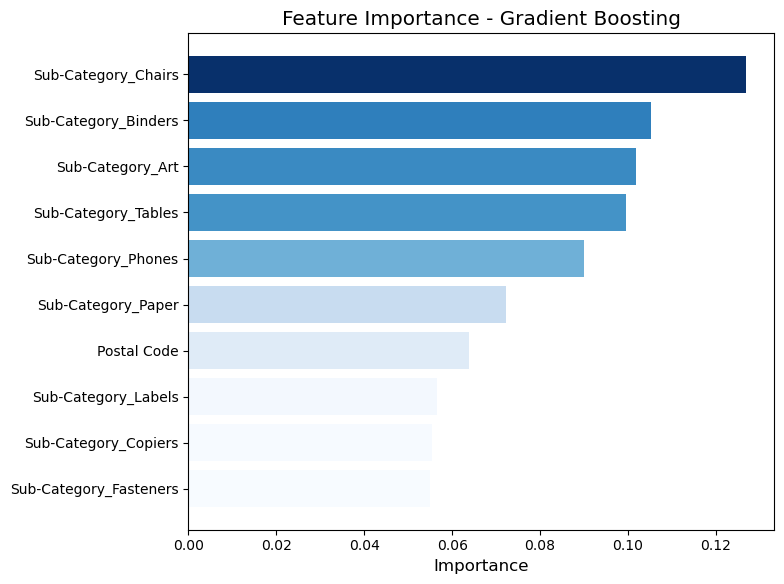

Top 10 Important Features:
                   Feature  Importance
13     Sub-Category_Chairs    0.126867
11    Sub-Category_Binders    0.105208
10        Sub-Category_Art    0.101925
24     Sub-Category_Tables    0.099553
21     Sub-Category_Phones    0.090101
20      Sub-Category_Paper    0.072360
0              Postal Code    0.063828
18     Sub-Category_Labels    0.056520
14    Sub-Category_Copiers    0.055471
16  Sub-Category_Fasteners    0.054950

=== HistGradientBoosting ===
✅ Best Params: {'min_samples_leaf': 10, 'max_iter': 100, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 0.5}
📉 MSE: 1.43
📈 RMSE: 1.20
📊 R² Score: 0.45
⚠️  HistGradientBoosting does not support feature importance.

=== XGBoost ===
✅ Best Params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
📉 MSE: 1.49
📈 RMSE: 1.22
📊 R² Score: 0.43


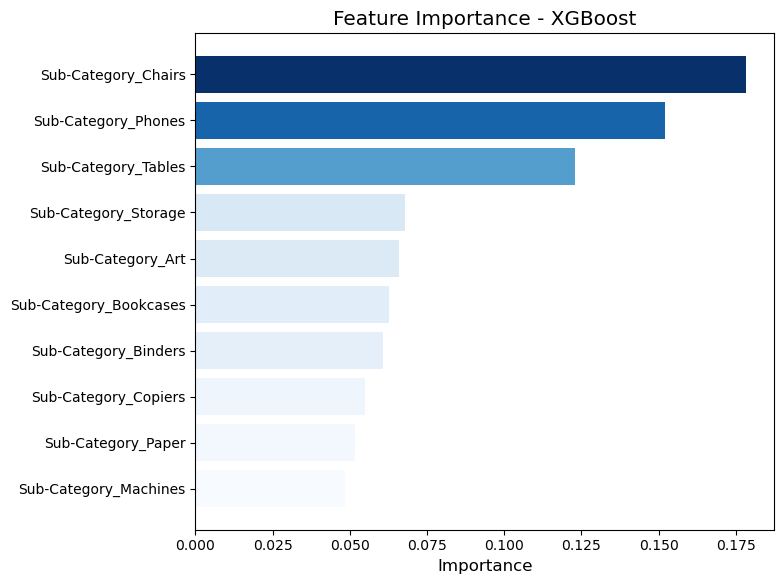

Top 10 Important Features:
                   Feature  Importance
13     Sub-Category_Chairs    0.178430
21     Sub-Category_Phones    0.152063
24     Sub-Category_Tables    0.122946
22    Sub-Category_Storage    0.067793
10        Sub-Category_Art    0.066041
12  Sub-Category_Bookcases    0.062768
11    Sub-Category_Binders    0.060884
14    Sub-Category_Copiers    0.054889
20      Sub-Category_Paper    0.051513
19   Sub-Category_Machines    0.048362

=== LightGBM ===
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001472 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 325
[LightGBM] [Info] Number of data points in the train set: 7840, number of used features: 25
[LightGBM] [Info] Start training from score 4.148515
[LightGBM] [Warning] No further splits wit

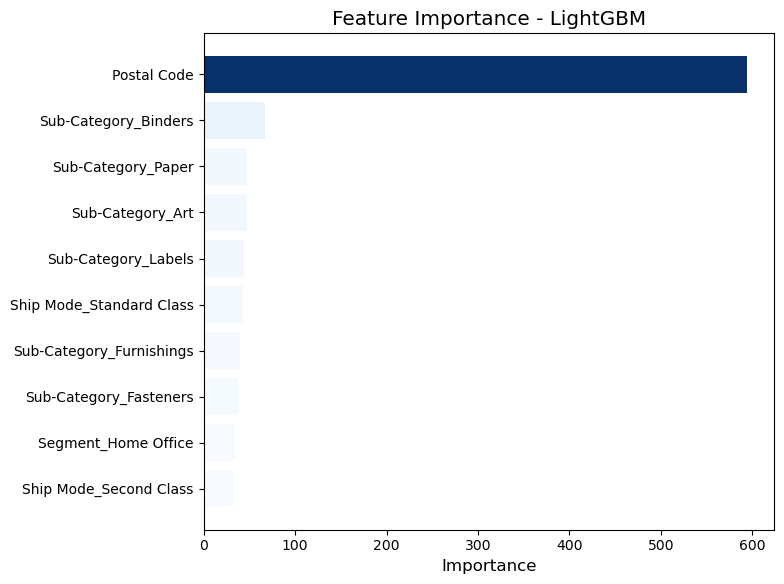

Top 10 Important Features:
                     Feature  Importance
0                Postal Code         594
11      Sub-Category_Binders          67
20        Sub-Category_Paper          47
10          Sub-Category_Art          47
18       Sub-Category_Labels          44
3   Ship Mode_Standard Class          43
17  Sub-Category_Furnishings          40
16    Sub-Category_Fasteners          39
5        Segment_Home Office          34
2     Ship Mode_Second Class          33


In [25]:
#prediction model hyperparameter tuning, training and evaluation 

# Preprocessing for model training
# Columns to drop
columns_to_drop = ['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Product ID', 
                   'Product Name', 'Order Date', 'Ship Date', 'Country', 'City', 'State', 'Category']
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# Categorical columns to encode
categorical_cols = ['Ship Mode', 'Segment', 'Region', 'Sub-Category']
categorical_cols = [col for col in categorical_cols if col in df.columns]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Drop any remaining non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=['number']).columns
df.drop(columns=non_numeric_cols, inplace=True)

# Separate features and target
X = df.drop(columns=['Sales'])
y = np.log1p(df['Sales'])  # Log-transform target to handle skewness

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)  # Retain column names for feature importance

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Models to Evaluate 
models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "LightGBM": lgb.LGBMRegressor(random_state=42)
}

# Hyperparameter grids for RandomizedSearchCV
param_grid = {
    "Random Forest": {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True, False]
    },
    "Gradient Boosting": {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.7, 0.8, 1.0]
    },
    "HistGradientBoosting": {
        'learning_rate': [0.01, 0.05, 0.1],
        'max_iter': [100, 200, 300],
        'max_depth': [None, 10],
        'min_samples_leaf': [10, 20, 50],
        'l2_regularization': [0.0, 0.1, 0.5]
    },
    "XGBoost": {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    },
    "LightGBM": {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'num_leaves': [31, 64, 128],
        'min_child_samples': [20, 30, 50]
    }
}

# Hyperparameter Tuning and Model Evaluation
best_models = {}
for name, model in models.items():
    print(f"\n=== {name} ===")
    
    # Hyperparameter tuning using RandomizedSearchCV
    random_search = RandomizedSearchCV(
        model,
        param_distributions=param_grid[name],
        n_iter=10,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1,
        random_state=42
    )
    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_
    best_models[name] = best_model

    # Predict and evaluate
    y_pred = best_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"✅ Best Params: {random_search.best_params_}")
    print(f"📉 MSE: {mse:.2f}")
    print(f"📈 RMSE: {rmse:.2f}")
    print(f"📊 R² Score: {r2:.2f}")

    # Plot Feature Importance
    if hasattr(best_model, "feature_importances_"):
        importances = best_model.feature_importances_
    elif hasattr(best_model, "coef_"):
        importances = np.abs(best_model.coef_)
    else:
        print(f"⚠️  {name} does not support feature importance.")
        continue

    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    # Keep only top 10 features
    top_features = feature_importance_df.head(10)
    
    # Normalize the importance values for the colormap
    norm = mcolors.Normalize(vmin=top_features['Importance'].min(), vmax=top_features['Importance'].max())
    colors = cm.Blues(norm(top_features['Importance']))

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.barh(top_features['Feature'], top_features['Importance'], color=colors)
    plt.gca().invert_yaxis()
    plt.title(f'Feature Importance - {name}')
    plt.xlabel('Importance')
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.tight_layout()
    plt.show()

    # Print Top 10 Features
    print("Top 10 Important Features:")
    print(top_features)